# Random LASSO 재현 (v2)

논문 *Hi-LASSO* Section 3 벤치마크의 **Random LASSO**(Wang 2011, 2단계 부트스트랩)를 재현한다.
데이터·채점은 `lib/`의 generate_data·scoring을 그대로 재사용(LASSO·ENet과 **동일 데이터**), 솔버만 `lib/random_lasso.py`로 교체.
**우선 Dataset I·II만**(III·IV는 부트스트랩이 무거워 미룸).

# Part A · 준비

## 1. 환경 & 모듈 import

이 노트북은 **R을 쓰지 않는다**(내부 솔버 = sklearn LassoCV). lib 3모듈 중 solver는 불필요.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join("..", "lib")))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings; warnings.filterwarnings("ignore")   # LassoCV 수렴 경고 억제

import generate_data as gd
from generate_data import DATASETS, SIGMA, BASE_SEED, SEED_BETA, build_beta, generate_split, snr
import scoring
from scoring import rme, rme_nonzeros, rmse, f1_selection, aucpr
import random_lasso
from random_lasso import fit_random_lasso

print("modules loaded (R 불필요, 내부 솔버 = sklearn LassoCV)")

modules loaded (R 불필요, 내부 솔버 = sklearn LassoCV)


## 2. 전역 설정

`DATASETS_RL`로 Dataset I·II만 대상(III·IV는 이름만 추가하면 확장). threshold는 **반복마다 검증셋 예측오차(MSE) 최소로 자동 선택**(정직; 참 β 미사용, 01/02의 λ 선택과 동일 원리).

In [2]:
METHOD    = "RandomLASSO"
N_REPEAT  = 10
L         = 30          # 부트스트랩 배수: B = floor(L*p/q)
# threshold는 반복마다 검증셋 MSE 최소로 자동 선택 (정직; 참 β 미사용)
DATASETS_RL = {k: DATASETS[k] for k in ["Dataset I", "Dataset II"]}
print("대상:", list(DATASETS_RL.keys()), "| L=%d, N_REPEAT=%d, threshold=검증셋 자동선택" % (L, N_REPEAT))

대상: ['Dataset I', 'Dataset II'] | L=30, N_REPEAT=10, threshold=검증셋 자동선택


## 3. lib 검산 & 부트스트랩 수

동일 데이터 SNR과 각 데이터셋의 부트스트랩 수 B를 확인.

In [3]:
for name, cfg in DATASETS_RL.items():
    beta = build_beta(cfg)
    tr, va, te = generate_split(cfg, beta, rep=0)
    print("%-11s p=%-5d n_tr=%-4d SNR=%.3f  B=floor(L*p/n)=%d" % (
        name, cfg["p"], cfg["n_tr"], snr(cfg, beta), (L*cfg["p"])//cfg["n_tr"]))

Dataset I   p=100   n_tr=50   SNR=2.733  B=floor(L*p/n)=60


Dataset II  p=1000  n_tr=100  SNR=4.419  B=floor(L*p/n)=300


# Part B · 한 번 돌려보기

## 4. 단일 데모 — 중요도 점수 (rep 0)

λ 탐색 자리 대체. Procedure 1이 **참 비영 변수(초록)** 에 높은 중요도를 주고 잡음(빨강)엔 낮게 주는지 확인.

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.370894e-01, tolerance: 1.248e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.399269e-01, tolerance: 1.618e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.104670e-01, tolerance: 1.732e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.008397e-01, tolerance: 2.541e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.649108e-01, tolerance: 1.437e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.557894e-01, tolerance: 1.437e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.603852e-01, tolerance: 2.009e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.017668e-01, tolerance: 2.440e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.120808e-01, tolerance: 4.338e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.550166e-01, tolerance: 2.998e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

...

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.441459e-01, tolerance: 2.286e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.439078e+00, tolerance: 4.660e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.271175e-01, tolerance: 3.313e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.975641e-01, tolerance: 3.313e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.394191e-01, tolerance: 3.064e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.657340e-01, tolerance: 3.852e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.960504e-01, tolerance: 3.964e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.509532e-01, tolerance: 3.461e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.122719e+00, tolerance: 4.717e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.656665e-01, tolerance: 3.618e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

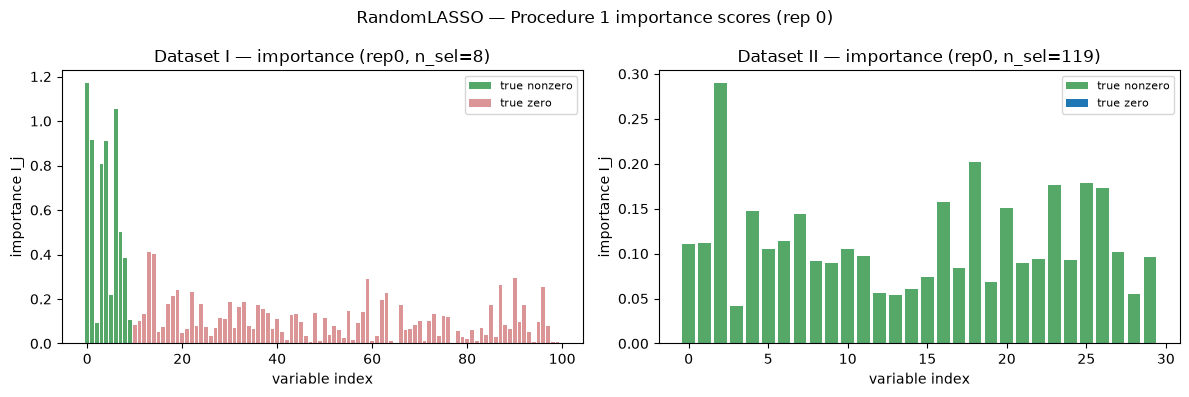

In [4]:
fig, axes = plt.subplots(1, len(DATASETS_RL), figsize=(6*len(DATASETS_RL), 4))
for ax, (name, cfg) in zip(np.atleast_1d(axes), DATASETS_RL.items()):
    beta = build_beta(cfg)
    (Xtr, ytr), (Xval, yval), _ = generate_split(cfg, beta, 0)
    r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, random_state=0)
    k = 30 if cfg["p"] > 100 else cfg["p"]
    idx = np.arange(k); true = (beta[:k] != 0)
    ax.bar(idx[true], r["importance_"][:k][true], color="#55A868", label="true nonzero")
    ax.bar(idx[~true], r["importance_"][:k][~true], color="#C44E52", alpha=0.6, label="true zero")
    ax.set_xlabel("variable index"); ax.set_ylabel("importance I_j")
    ax.set_title(f"{name} — importance (rep0, n_sel={r['n_selected']})")
    ax.legend(fontsize=8)
fig.suptitle(f"{METHOD} — Procedure 1 importance scores (rep 0)")
plt.tight_layout(); plt.show()

## 5. β̂ vs β — rep 0 (계수 미리보기)

LASSO가 죽이던 음수 계수 β₃·β₆·β₁₀를 Random LASSO가 살리는지 미리보기(§11에서 10회로 확장).

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.370894e-01, tolerance: 1.248e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.683201e-01, tolerance: 1.665e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.107513e-01, tolerance: 1.737e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.341391e-01, tolerance: 1.860e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.338277e-01, tolerance: 1.200e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.139914e-01, tolerance: 1.997e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.877817e-01, tolerance: 1.549e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.069578e-01, tolerance: 1.788e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

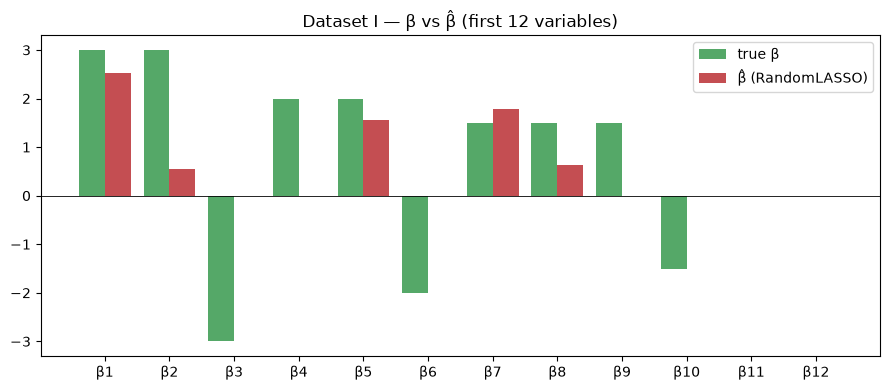

In [5]:
cfg = DATASETS_RL["Dataset I"]; beta = build_beta(cfg)
(Xtr, ytr), (Xval, yval), _ = generate_split(cfg, beta, 0)
r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, random_state=0); bhat = r["coef_"]
k = 12; idx = np.arange(k); w = 0.4
plt.figure(figsize=(9, 4))
plt.bar(idx - w/2, beta[:k], w, label="true β", color="#55A868")
plt.bar(idx + w/2, bhat[:k], w, label=f"β̂ ({METHOD})", color="#C44E52")
plt.axhline(0, color='k', lw=0.6); plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title("Dataset I — β vs β̂ (first 12 variables)")
plt.legend(); plt.tight_layout(); plt.show()

# Part C · 본 실험 (I·II × 10회)

## 6. 전체 실험 루프

rep마다 `fit_random_lasso(Xtr,ytr)` → 채점. bhat·importance·n_selected를 details에 저장.

In [6]:
def run_experiment():
    records, details = [], {}
    for name, cfg in DATASETS_RL.items():
        beta = build_beta(cfg)
        d = dict(beta=beta, bhats=[], beta_hats=[], importances=[], n_selected=[], thresholds=[])
        for rep in range(N_REPEAT):
            (Xtr, ytr), (Xval, yval), (Xte, yte) = generate_split(cfg, beta, rep)
            r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, random_state=rep)
            bhat = r["coef_"]; pred = Xte @ bhat
            records.append(dict(dataset=name, method=METHOD, rep=rep,
                                RME_All=rme(bhat, beta, cfg),
                                RME_Nonzeros=rme_nonzeros(bhat, beta, cfg),
                                RMSE=rmse(yte, pred),
                                aucpr=aucpr(r["beta_hat_"], beta),
                                **f1_selection(bhat, beta)))
            d["bhats"].append(bhat); d["beta_hats"].append(r["beta_hat_"])
            d["importances"].append(r["importance_"])
            d["n_selected"].append(r["n_selected"]); d["thresholds"].append(r["threshold_"])
        details[name] = d
        print(f"{name}: {N_REPEAT} reps done")
    return records, details

records, details = run_experiment()
df = pd.DataFrame(records)
metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1", "aucpr"]
print("총 레코드:", len(records))

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.370894e-01, tolerance: 1.248e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.683201e-01, tolerance: 1.665e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.573828e-01, tolerance: 1.343e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.079204e-01, tolerance: 1.356e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.504145e-01, tolerance: 1.643e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.063719e-01, tolerance: 1.643e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.276281e-01, tolerance: 2.091e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.987963e-01, tolerance: 1.421e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.338277e-01, tolerance: 1.200e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.139914e-01, tolerance: 1.997e-01
  model = cd_fast.enet_coordinate_descent(


...

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.630620e-01, tolerance: 4.839e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.329622e+00, tolerance: 5.694e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.758139e-01, tolerance: 4.443e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.536045e-01, tolerance: 5.624e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.321131e-01, tolerance: 5.039e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.133213e-01, tolerance: 5.039e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

Dataset II: 10 reps done
총 레코드: 20


/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.791084e-01, tolerance: 5.396e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.740175e-01, tolerance: 4.959e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

## 7. 결과 표 (평균 ± 표준오차)

In [7]:
summary = df.groupby(["dataset", "method"])[metrics].agg(["mean", "sem"]).round(4)
summary

RME_All         RME_Nonzeros            RMSE          \
                          mean     sem         mean     sem    mean     sem   
dataset    method                                                             
Dataset I  RandomLASSO  0.8501  0.0961       0.6665  0.0778  4.5327  0.2201   
Dataset II RandomLASSO  1.5156  0.0602       1.3907  0.0422  5.0055  0.3386   

                            f1           aucpr          
                          mean     sem    mean     sem  
dataset    method                                       
Dataset I  RandomLASSO  0.4921  0.0335  0.5775  0.0372  
Dataset II RandomLASSO  0.3217  0.0251  0.3559  0.0218

## 8. 논문 Table 3 비교 (Random_EG 열)

우리 구현은 Proc2에 순수 LASSO를 쓰므로 논문의 **Random_EG**(generic) 열과 비교.

In [8]:
PAPER_RANDOM_EG = {   # 논문 Table 3, Random_EG 열 (AUCPR은 논문 미제공 → 비교 제외)
    "Dataset I":  dict(RME_All=1.4688, RME_Nonzeros=1.4238, RMSE=4.1216, f1=0.4237),
    "Dataset II": dict(RME_All=2.4894, RME_Nonzeros=2.4026, RMSE=5.7314, f1=0.1816),
    "Dataset III": dict(RME_All=4.7696, RME_Nonzeros=4.1757, RMSE=7.3016, f1=0.4114),
    "Dataset IV":  dict(RME_All=4.3766, RME_Nonzeros=4.3766, RMSE=7.0131, f1=0.5860),
}
paper_metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1"]   # 논문에 있는 지표만
rows = []
for ds in DATASETS_RL:
    if ds not in PAPER_RANDOM_EG: continue
    ours = df[df.dataset == ds][paper_metrics].mean()
    for m in paper_metrics:
        rows.append(dict(dataset=ds, metric=m, ours=round(float(ours[m]), 4), paper=PAPER_RANDOM_EG[ds][m]))
compare = pd.DataFrame(rows)
compare["ratio(ours/paper)"] = (compare["ours"] / compare["paper"]).round(2)
compare

,dataset,metric,ours,paper,ratio(ours/paper)
0,Dataset I,RME_All,0.8501,1.4688,0.58
1,Dataset I,RME_Nonzeros,0.6665,1.4238,0.47
2,Dataset I,RMSE,4.5327,4.1216,1.10
3,Dataset I,f1,0.4921,0.4237,1.16
4,Dataset II,RME_All,1.5156,2.4894,0.61
5,Dataset II,RME_Nonzeros,1.3907,2.4026,0.58
6,Dataset II,RMSE,5.0055,5.7314,0.87
7,Dataset II,f1,0.3217,0.1816,1.77


# Part D · 분포 시각화

## 9. 지표 막대 (평균 ± 표준오차)

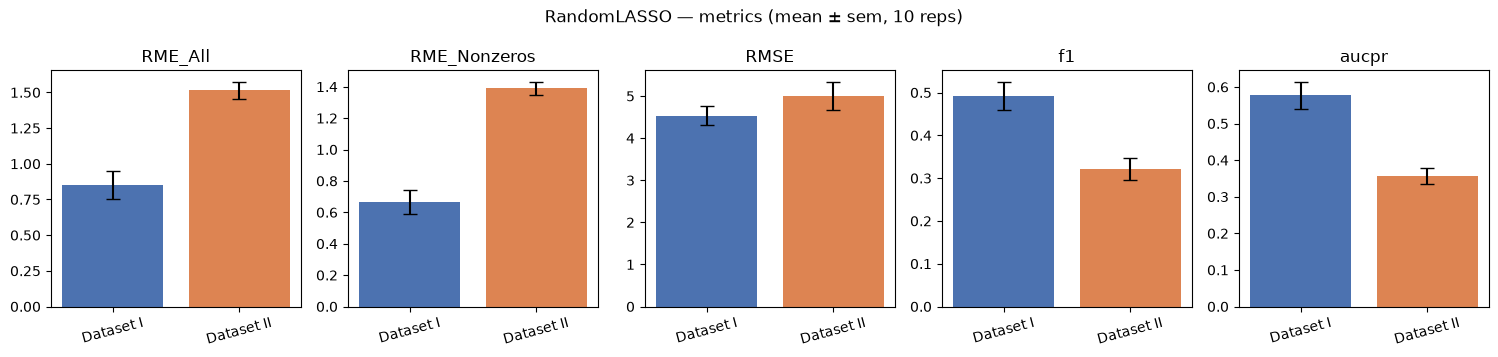

In [9]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.6))
for ax, m in zip(axes, metrics):
    sub = df.groupby("dataset")[m].agg(["mean", "sem"])
    ax.bar(range(len(sub)), sub["mean"], yerr=sub["sem"], capsize=5, color=colors[:len(sub)])
    ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub.index, rotation=15); ax.set_title(m)
fig.suptitle(f"{METHOD} — metrics (mean ± sem, {N_REPEAT} reps)")
plt.tight_layout(); plt.show()

## 10. 지표 분포 박스플롯 (10회)

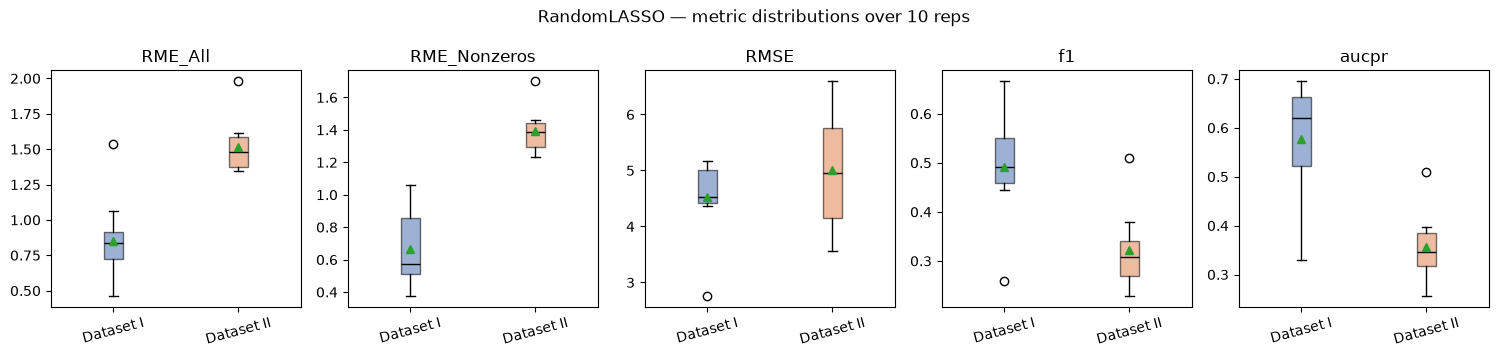

In [10]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(15, 3.6))
for ax, m in zip(axes, metrics):
    data = [df[df.dataset == ds][m].values for ds in DATASETS_RL]
    bp = ax.boxplot(data, patch_artist=True, showmeans=True, medianprops=dict(color='k'))
    for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
    ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels(list(DATASETS_RL.keys()), rotation=15); ax.set_title(m)
fig.suptitle(f"{METHOD} — metric distributions over {N_REPEAT} reps")
plt.tight_layout(); plt.show()

## 11. 계수 부호 산점도 (10회)

Dataset I 앞 10개. Random LASSO가 음수 계수 β₃·β₆·β₁₀를 LASSO보다 잘 살리는지가 관전 포인트.

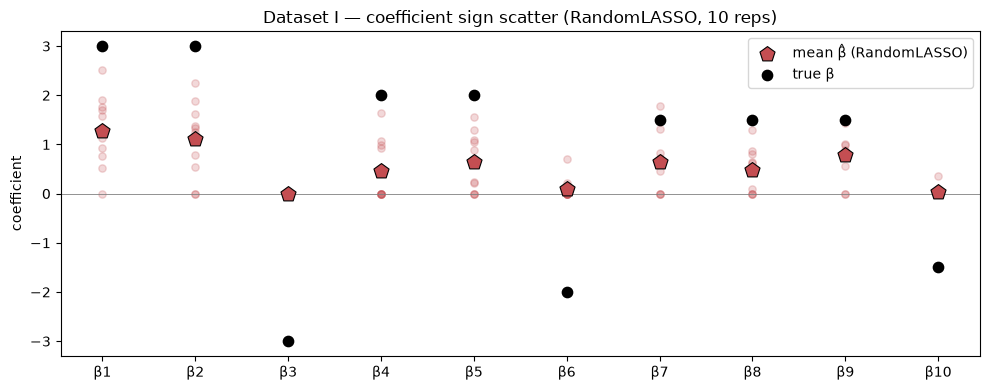

In [11]:
k = 10; d = details["Dataset I"]; beta_I = d["beta"]
bhats = np.array([bh[:k] for bh in d["bhats"]])
idx = np.arange(k)
plt.figure(figsize=(10, 4))
for rep in range(N_REPEAT):
    plt.scatter(idx, bhats[rep], color="#C44E52", alpha=0.22, s=28, zorder=2)
plt.scatter(idx, bhats.mean(0), color="#C44E52", marker='p', s=130, edgecolor='k', lw=0.8, zorder=3, label=f"mean β̂ ({METHOD})")
plt.scatter(idx, beta_I[:k], color='k', marker='o', s=55, zorder=4, label="true β")
plt.axhline(0, color='gray', lw=0.6); plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title(f"Dataset I — coefficient sign scatter ({METHOD}, {N_REPEAT} reps)")
plt.ylabel("coefficient"); plt.legend(); plt.tight_layout(); plt.show()

## 12. 선택 변수 수 분포 (λ 안정성 대체)

반복별 선택 변수 수. 점선 = 참 비영 개수(과다/과소선택 확인).

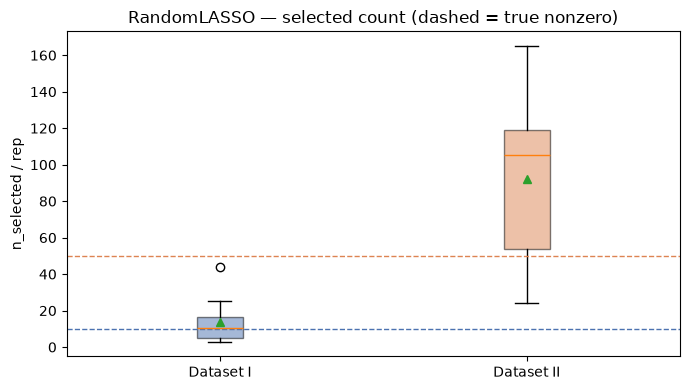

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [details[name]["n_selected"] for name in DATASETS_RL]
bp = ax.boxplot(data, patch_artist=True, showmeans=True)
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for patch, c in zip(bp['boxes'], cs): patch.set_facecolor(c); patch.set_alpha(0.5)
for i, name in enumerate(DATASETS_RL):
    ax.axhline(int((details[name]["beta"] != 0).sum()), color=cs[i], ls="--", lw=1)
ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels(list(DATASETS_RL.keys()))
ax.set_ylabel("n_selected / rep"); ax.set_title(f"{METHOD} — selected count (dashed = true nonzero)")
plt.tight_layout(); plt.show()

## 13. 검증 MSE vs threshold 곡선 (I·II, rep 0)

01/02의 "λ 탐색 곡선"의 Random 판. 반복마다 t를 **검증 예측오차 최소**로 고르는데, 그 U자 곡선과 선택된 t(빨간 점선)를 보여준다. 정답 β 없이 데이터로 t가 정해지는 과정.

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.370894e-01, tolerance: 1.248e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.683201e-01, tolerance: 1.665e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.281711e-01, tolerance: 1.095e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.504145e-01, tolerance: 1.643e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.961878e-01, tolerance: 1.248e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.157915e-01, tolerance: 1.653e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.798659e-01, tolerance: 1.679e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.001648e-01, tolerance: 1.667e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.120808e-01, tolerance: 4.338e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.550166e-01, tolerance: 2.998e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

...

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.587466e-01, tolerance: 3.498e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.473949e-01, tolerance: 3.240e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.614940e-01, tolerance: 4.000e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.924591e-01, tolerance: 4.602e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.040126e-01, tolerance: 3.852e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.168002e+00, tolerance: 4.106e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.116403e-01, tolerance: 3.984e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.509532e-01, tolerance: 3.461e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.122719e+00, tolerance: 4.717e-01
  model = cd_fast.enet_coordinate_descent(
/Users/boseung/Desktop/Lecture/UNLV/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.019194e+00, tolerance: 4.717e-01
  model = cd_fast.enet_coordinate_descent(


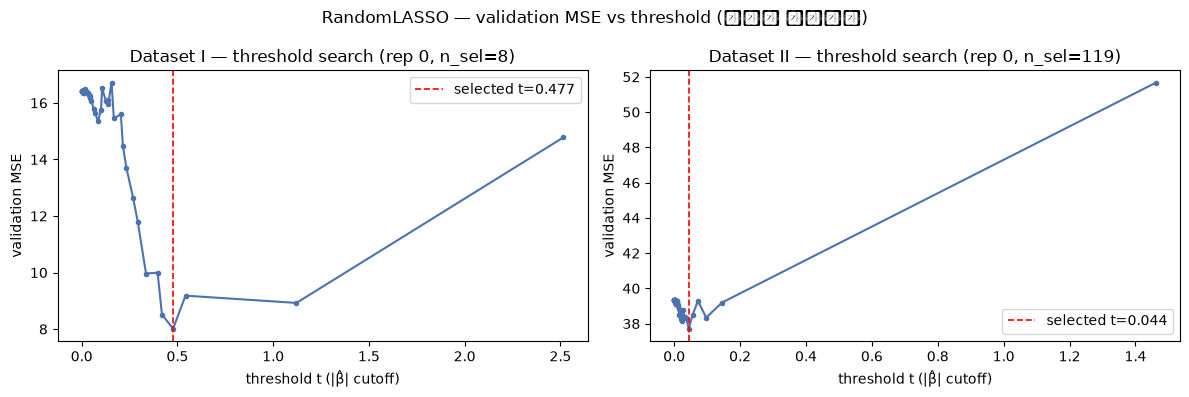

In [13]:
demo = ["Dataset I", "Dataset II"]
fig, axes = plt.subplots(1, len(demo), figsize=(6*len(demo), 4))
for ax, name in zip(np.atleast_1d(axes), demo):
    cfg = DATASETS_RL[name]; beta = build_beta(cfg)
    (Xtr, ytr), (Xval, yval), _ = generate_split(cfg, beta, 0)
    r = fit_random_lasso(Xtr, ytr, Xval, yval, L=L, random_state=0)
    ax.plot(r["thr_grid_"], r["thr_mse_"], marker='.', color="#4C72B0")
    ax.axvline(r["threshold_"], color='r', ls='--', lw=1.2, label=f"selected t={r['threshold_']:.3f}")
    ax.set_xlabel("threshold t (|β̂| cutoff)"); ax.set_ylabel("validation MSE")
    ax.set_title(f"{name} — threshold search (rep 0, n_sel={r['n_selected']})")
    ax.legend()
fig.suptitle(f"{METHOD} — validation MSE vs threshold (검증셋 자동선택)")
plt.tight_layout(); plt.show()

## 14. 선택 threshold 분포 (10회)

검증이 반복마다 고른 t의 분포. 좁을수록 threshold 선택이 안정적(01/02 λ 안정성의 Random 판).

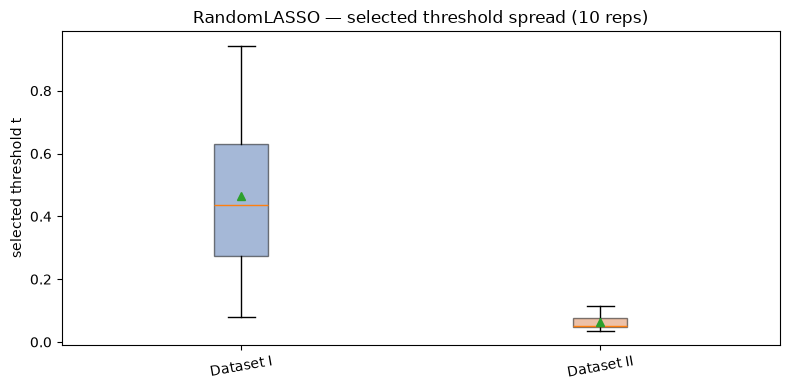

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [details[name]["thresholds"] for name in DATASETS_RL]
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bp = ax.boxplot(data, patch_artist=True, showmeans=True)
for patch, c in zip(bp['boxes'], cs): patch.set_facecolor(c); patch.set_alpha(0.5)
ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels(list(DATASETS_RL.keys()), rotation=10)
ax.set_ylabel("selected threshold t"); ax.set_title(f"{METHOD} — selected threshold spread ({N_REPEAT} reps)")
plt.tight_layout(); plt.show()

## 15. Precision-Recall 곡선 & AUCPR (rep 0)

threshold-free 평가. |β̂| 순위로 그린 PR 곡선과 그 면적(AUCPR). 곡선이 오른쪽 위에 붙을수록(면적 큼) 신호/잡음 분리가 좋다. 임계값 선택 문제 자체를 우회하는 정직한 지표.

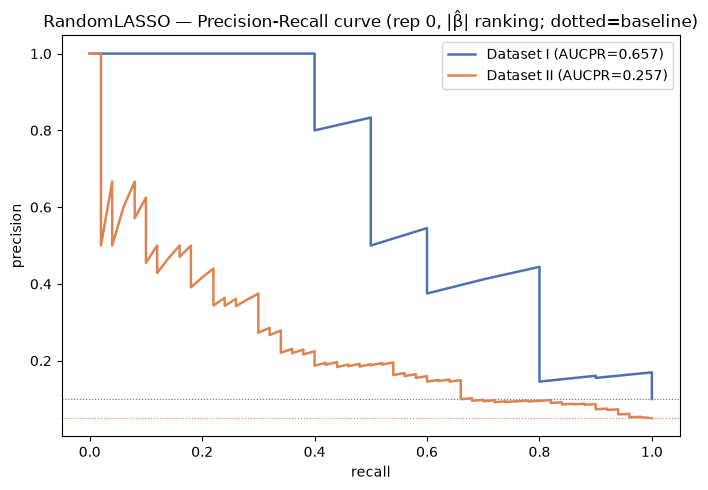

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score
fig, ax = plt.subplots(figsize=(7, 5))
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for i, name in enumerate(DATASETS_RL):
    beta = details[name]["beta"]; score = np.abs(details[name]["beta_hats"][0])
    ytrue = (beta != 0).astype(int)
    prec, rec, _ = precision_recall_curve(ytrue, score)
    ap = average_precision_score(ytrue, score)
    ax.plot(rec, prec, color=cs[i], lw=1.8, label=f"{name} (AUCPR={ap:.3f})")
    ax.axhline(ytrue.mean(), color=cs[i], ls=":", lw=0.8)   # baseline = 유병률
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title(f"{METHOD} — Precision-Recall curve (rep 0, |β̂| ranking; dotted=baseline)")
ax.legend(); plt.tight_layout(); plt.show()